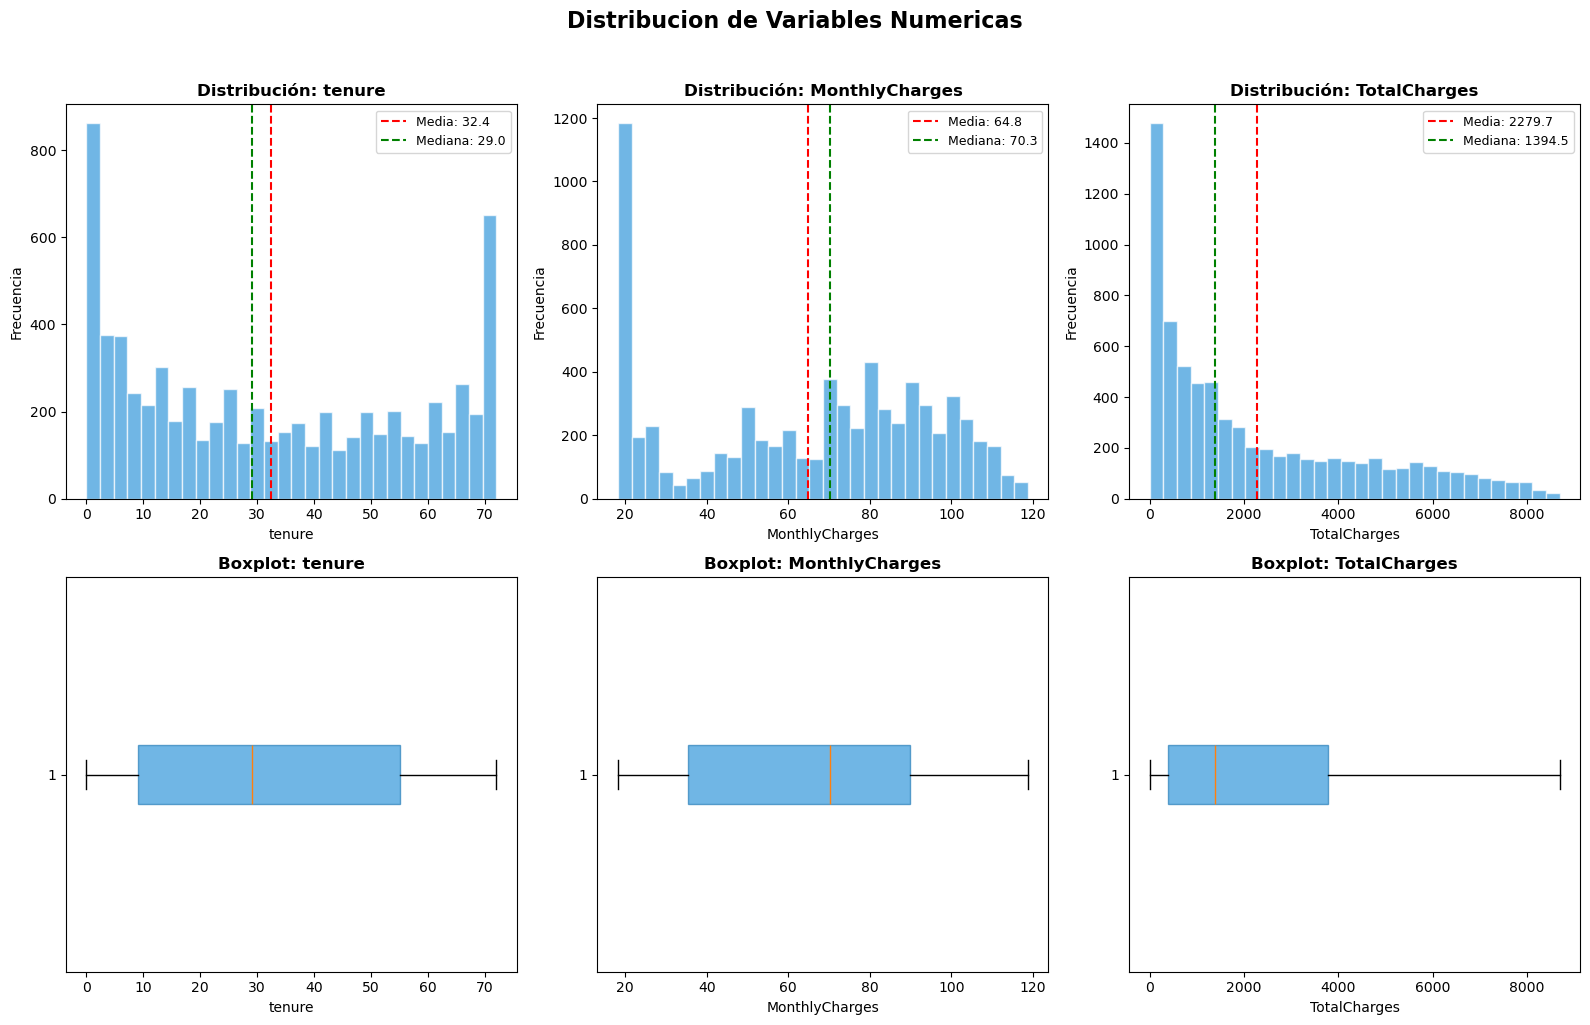

In [41]:
# ============================================================
# ETAPA: Análisis Univariado
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/telco_churn_clean.csv")

# --- VARIABLES NUMÉRICAS ---

fig, axes = plt.subplots(2,3, figsize=(16,10))
fig.suptitle("Distribucion de Variables Numericas",
            fontsize=16, fontweight="bold", y=1.02)

vars_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

for i, var in enumerate(vars_numericas):
    # Histograma con KDE
    axes[0,i].hist(df[var], bins=30, color="#3498db", edgecolor="white", alpha=0.7)
    axes[0,i].set_title(f"Distribución: {var}", fontsize=12, fontweight="bold")
    axes[0,i].set_xlabel(var, fontsize=10)
    axes[0,i].set_ylabel("Frecuencia", fontsize=10)

    mean_val = df[var].mean()
    median_val = df[var].median()
    axes[0,i].axvline(mean_val, color= "red", linestyle = "--", label=f"Media: {mean_val:.1f}")
    axes[0,i].axvline(median_val, color= "green", linestyle="--", label=f"Mediana: {median_val:.1f}")
    axes[0,i].legend(fontsize=9)

    # Boxplot
    axes[1,i].boxplot(df[var].dropna(), vert=False, patch_artist=True, 
                    boxprops=dict(facecolor="#3498db", color="#2980b9", alpha=0.7))
    axes[1,i].set_title(f"Boxplot: {var}", fontweight="bold", fontsize=12)
    axes[1,i].set_xlabel(var)

plt.tight_layout()
plt.savefig('../visuals/02_univariado_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# --- ESTADÍSTICAS DETALLADAS POR VARIABLE NUMÉRICA ---

for var in vars_numericas:
    print(f"\n{'='*40}")
    print(f"VARIABLE: {var}")
    print(f"{'='*40}")
    print(f"  Media:              {df[var].mean():.2f}")
    print(f"  Mediana:            {df[var].median():.2f}")
    print(f"  Desv. Estándar:     {df[var].std():.2f}")
    print(f"  Mínimo:             {df[var].min():.2f}")
    print(f"  Máximo:             {df[var].max():.2f}")
    print(f"  Asimetría (skew):   {df[var].skew():.2f}")

    # Interpretación del skew
    skew = df[var].skew()
    if skew > 0.5:
        print(f"  → Distribución sesgada a la DERECHA (cola larga hacia valores altos)")
    elif skew < -0.5:
        print(f"  → Distribución sesgada a la IZQUIERDA (cola larga hacia valores bajos)")
    else:
        print(f"  → Distribución aproximadamente SIMÉTRICA")


VARIABLE: tenure
  Media:              32.37
  Mediana:            29.00
  Desv. Estándar:     24.56
  Mínimo:             0.00
  Máximo:             72.00
  Asimetría (skew):   0.24
  → Distribución aproximadamente SIMÉTRICA

VARIABLE: MonthlyCharges
  Media:              64.76
  Mediana:            70.35
  Desv. Estándar:     30.09
  Mínimo:             18.25
  Máximo:             118.75
  Asimetría (skew):   -0.22
  → Distribución aproximadamente SIMÉTRICA

VARIABLE: TotalCharges
  Media:              2279.73
  Mediana:            1394.55
  Desv. Estándar:     2266.79
  Mínimo:             0.00
  Máximo:             8684.80
  Asimetría (skew):   0.96
  → Distribución sesgada a la DERECHA (cola larga hacia valores altos)


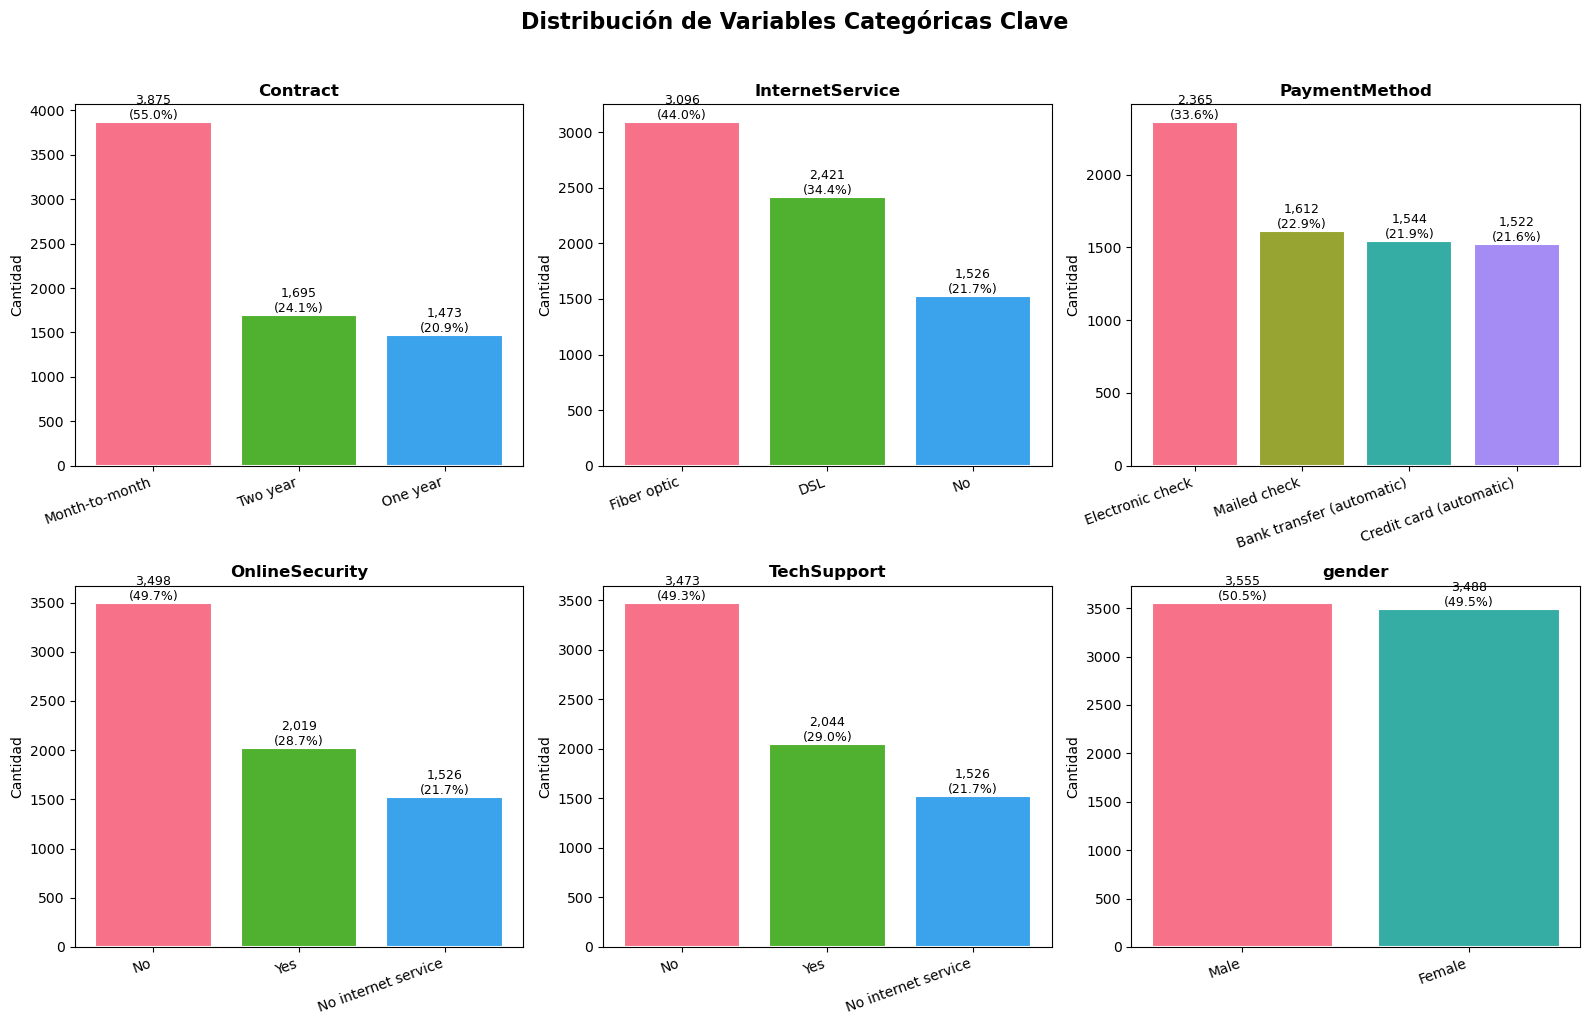

In [55]:
# --- VARIABLES CATEGÓRICAS ---
# Analizando las que son más relevantes estratégicamente

vars_cat_key = ['Contract', 'InternetService', 'PaymentMethod', 
                'OnlineSecurity', 'TechSupport', 'gender']

fig, axes = plt.subplots(2,3, figsize=(16, 10))
fig.suptitle("Distribución de Variables Categóricas Clave",
            fontsize=16, fontweight="bold", y=1.02)

axes_flat = axes.flatten()

for i, var in enumerate(vars_cat_key):
    counts = df[var].value_counts()
    bars = axes_flat[i].bar(range(len(counts)), counts.values,
                            color=sns.color_palette("husl", len(counts)),
                            edgecolor='white', linewidth=1.5)
    
    axes_flat[i].set_xticks(range(len(counts)))
    axes_flat[i].set_xticklabels(counts.index, rotation=20, ha='right')
    axes_flat[i].set_title(f'{var}', fontweight='bold', fontsize=12)
    axes_flat[i].set_ylabel('Cantidad')
    
    # Etiquetas con porcentaje
    total = len(df)
    for bar, val in zip(bars, counts.values):
        pct = val/total*100
        axes_flat[i].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                        f'{val:,}\n({pct:.1f}%)', 
                        ha='center', va='bottom', fontsize=9)
        
plt.tight_layout()
plt.savefig('../visuals/03_univariado_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Interpretación — Hallazgos del Análisis Univariado

---

#### **TENURE (Antigüedad en meses)**
* **Distribución BIMODAL:** Existe una concentración alta de clientes muy nuevos (0-5 meses) y clientes con alta fidelidad (60-72 meses).
* **Observación:** Poca densidad en los valores intermedios.
* **Insight:** Se identifican dos perfiles críticos: el segmento leal y el segmento de abandono temprano.

#### **MONTHLY CHARGES (Cargo mensual)**
* **Distribución:** Relativamente uniforme en el rango de **$20 - $110**.
* **Métricas clave:** Media $\approx$ $65/mes | Mediana $\approx$ $70/mes.
* **Nota:** Los cargos más bajos están asociados a clientes sin servicio de internet.

#### **TOTAL CHARGES (Cargo total acumulado)**
* **Comportamiento:** Fuerte sesgo a la derecha (muchos clientes con bajo gasto acumulado).
* **Correlación:** Directamente proporcional al *Tenure* (a mayor antigüedad, mayor acumulado).

#### **CONTRACT (Tipo de contrato)**
* **Month-to-Month:** 55% (Representa una **bandera roja** para el riesgo de churn).
* **One year:** 24%. (contratos anuales)
* **Two year:** 21%. (contratos bianuales)

#### **INTERNET SERVICE**
* **Fiber Optic:** 44%.
* **DSL:** 34%.
* **Sin Internet:** 22%.